In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/parkinson_dataset"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
import os
import shutil

source = "/content/parkinson_dataset/Parkinson's Dataset Final/New hand pd Dataset"
target = "/content/parkinson_clean"

healthy_src = os.path.join(source,"Healthy")
patient_src = os.path.join(source,"Parkinson's")

healthy_dst = os.path.join(target,"Healthy")
patient_dst = os.path.join(target,"Parkinson")

os.makedirs(healthy_dst,exist_ok=True)
os.makedirs(patient_dst,exist_ok=True)

for root, dirs, files in os.walk(healthy_src):
    for file in files:
        if file.lower().endswith((".png",".jpg",".jpeg")):
            shutil.copy(os.path.join(root,file),healthy_dst)

for root, dirs, files in os.walk(patient_src):
    for file in files:
        if file.lower().endswith((".png",".jpg",".jpeg")):
            shutil.copy(os.path.join(root,file),patient_dst)

In [4]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/parkinson_clean",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/parkinson_clean",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 512 files belonging to 2 classes.
Using 410 files for training.
Found 512 files belonging to 2 classes.
Using 102 files for validation.


In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
from tensorflow.keras import layers,models,regularizers
import tensorflow as tf

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [9]:
def transformer_block(x,embed_dim):

    attention = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=embed_dim
    )(x,x)

    x = layers.Add()([x,attention])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(embed_dim*2,activation="gelu")(x)
    ffn = layers.Dense(embed_dim)(ffn)

    x = layers.Add()([x,ffn])
    x = layers.LayerNormalization()(x)

    return x

In [19]:
inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = data_augmentation(inputs)

# CNN feature extractor
x = layers.Conv2D(32,3,activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64,3,activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128,3,activation="relu")(x)
# Patch embedding
x = layers.Conv2D(128,16,16)(x)
x = layers.Reshape((-1,128))(x)

# Transformer encoder
for _ in range(3):
    x = transformer_block(x,128)

x = layers.GlobalAveragePooling1D()(x)

# FCNN classifier
x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

x = layers.Dropout(0.2)(x)

x = layers.Dense(16,activation="relu")(x)

outputs = layers.Dense(2,activation="softmax")(x)

model = models.Model(inputs,outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 222, 222,  │        896 │ sequential_1[1][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 111, 111,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 109, 109,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 54, 54,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 52, 52,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 3, 3, 128) │  4,194,432 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 9, 128)    │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │    263,808 │ reshape_2[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 9, 128)    │          0 │ reshape_2[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 9, 128)    │     32,896 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 128)    │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten

 Total params: 5,289,298 (20.18 MB)

 Trainable params: 5,289,298 (20.18 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_parkinson_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

lr_schedule = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[checkpoint,early_stop,lr_schedule]
)

Epoch 1/40
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4977 - loss: 0.9185
Epoch 1: val_accuracy improved from -inf to 0.46078, saving model to best_parkinson_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.4980 - loss: 0.9151 - val_accuracy: 0.4608 - val_loss: 0.8296 - learning_rate: 1.0000e-04
Epoch 2/40
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4503 - loss: 0.8400
Epoch 2: val_accuracy improved from 0.46078 to 0.53922, saving model to best_parkinson_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4531 - loss: 0.8394 - val_accuracy: 0.5392 - val_loss: 0.8094 - learning_rate: 1.0000e-04
Epoch 3/40
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5098 - loss: 0.8348
Epoch 3: val_accuracy did not improve from 0.53922
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5067 - loss: 0.8352 - val_accuracy: 0.4608 - val_loss: 0.8180 - learning_rate: 1.0000e-04
Epoch 4/40
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step


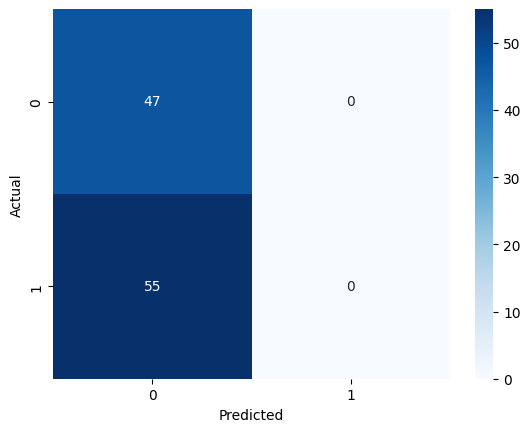

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true=[]
y_pred=[]

for images,labels in val_ds:
    preds=model.predict(images)
    preds=np.argmax(preds,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

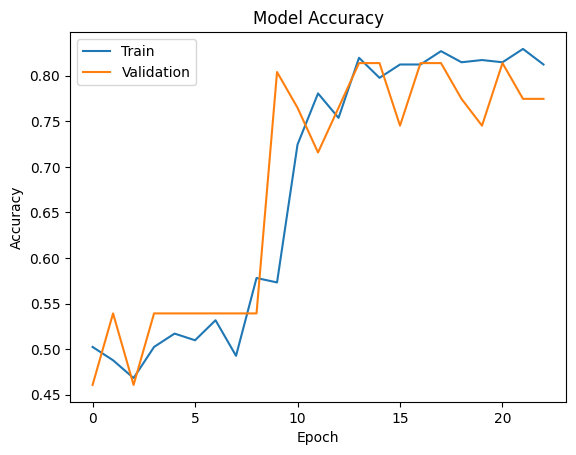

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

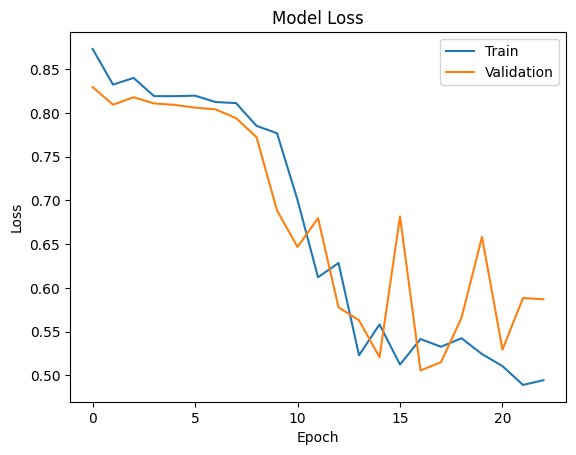

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

In [23]:
from tensorflow.keras.models import load_model

model = load_model("best_parkinson_model.keras")

In [24]:
y_true=[]
y_pred=[]

for images,labels in val_ds:
    preds=model.predict(images, verbose=0)
    preds=np.argmax(preds,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

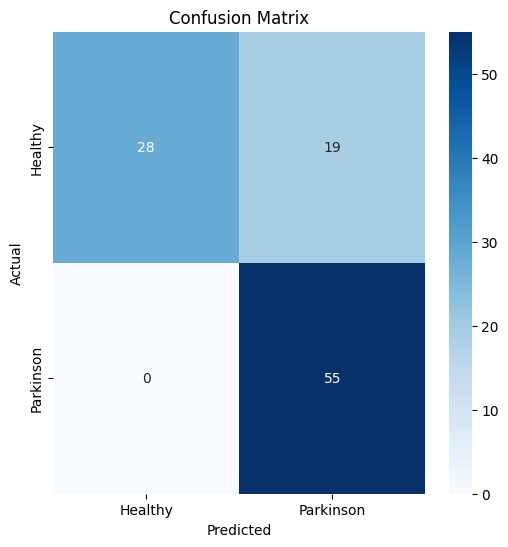

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy","Parkinson"],
            yticklabels=["Healthy","Parkinson"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()